# 🌿 Análisis Exploratorio y Visualización - Base de Datos de Plantas

In [1]:
from pymongo import MongoClient
from collections import Counter
import pandas as pd
import matplotlib.pyplot as plt
from PIL import Image
import requests
from io import BytesIO
import random

client = MongoClient("mongodb://localhost:27017/")
db = client["Repositorio_Plantas"]
docs = list(db["Docs"].find())

clases = {doc["_id"]: doc["clasificacion"] for doc in db["Clases"].find()}
fuentes = {doc["_id"]: doc["fuente"] for doc in db["Fuente"].find()}
formatos = {doc["_id"]: doc["formato"] for doc in db["Formato"].find()}


## Total de imágenes en la base de datos

In [2]:
print(f'Total de documentos/imágenes: {len(docs)}')

Total de documentos/imágenes: 58459


## Distribución de imágenes por clase

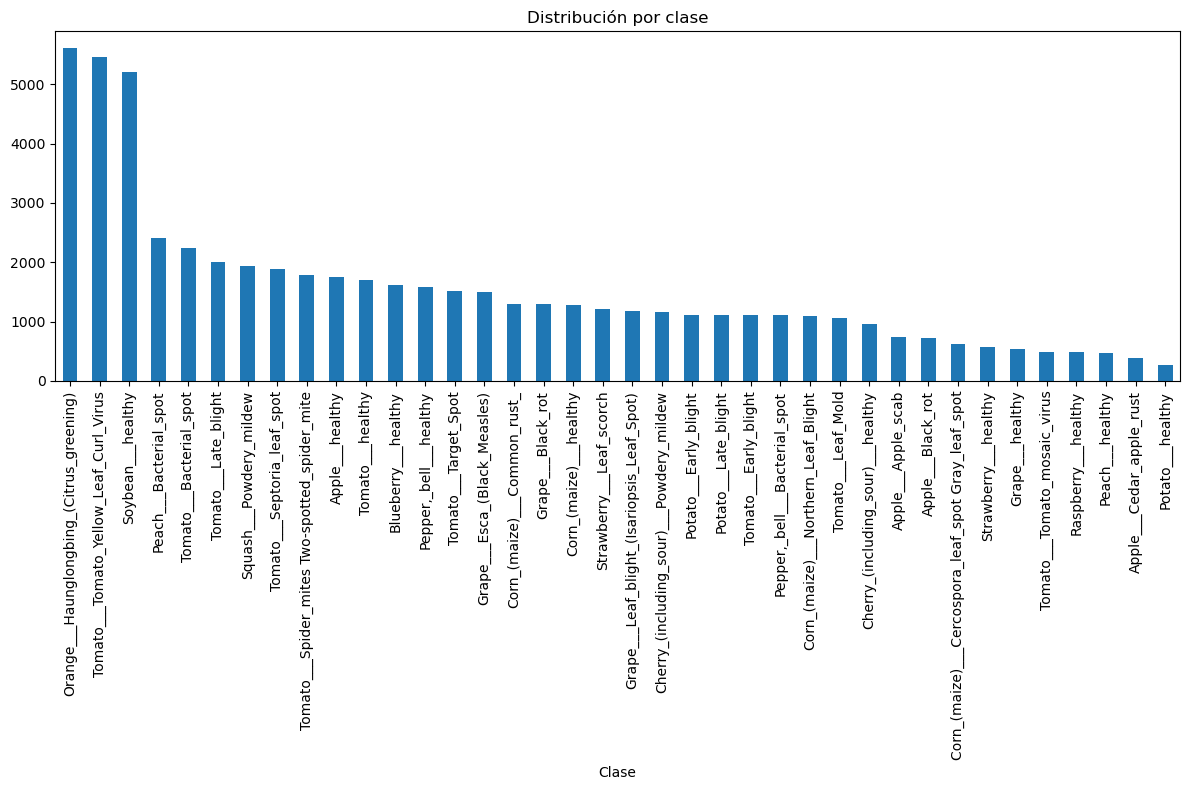

,Clase,Cantidad
15,Orange___Haunglongbing_(Citrus_greening),5612
37,Tomato___Tomato_Yellow_Leaf_Curl_Virus,5467
24,Soybean___healthy,5200
16,Peach___Bacterial_spot,2407
28,Tomato___Bacterial_spot,2237
31,Tomato___Late_blight,2011
25,Squash___Powdery_mildew,1945
33,Tomato___Septoria_leaf_spot,1881
34,Tomato___Spider_mites Two-spotted_spider_mite,1786
3,Apple___healthy,1748


In [3]:
conteo_clases = Counter(doc["clase"] for doc in docs if "clase" in doc)
conteo_nombres = {clases.get(k, "Desconocido"): v for k, v in conteo_clases.items()}
df_clases = pd.DataFrame(list(conteo_nombres.items()), columns=["Clase", "Cantidad"]).sort_values("Cantidad", ascending=False)
df_clases.plot(kind='bar', x='Clase', y='Cantidad', figsize=(12,8), legend=False, title="Distribución por clase")
plt.xticks(rotation=90)
plt.tight_layout()
plt.show()
df_clases


## Proporción de imágenes por clase

C:\Users\Pablo\AppData\Local\Temp\ipykernel_13416\4123746108.py:4: UserWarning: Tight layout not applied. The bottom and top margins cannot be made large enough to accommodate all axes decorations.
  plt.tight_layout()


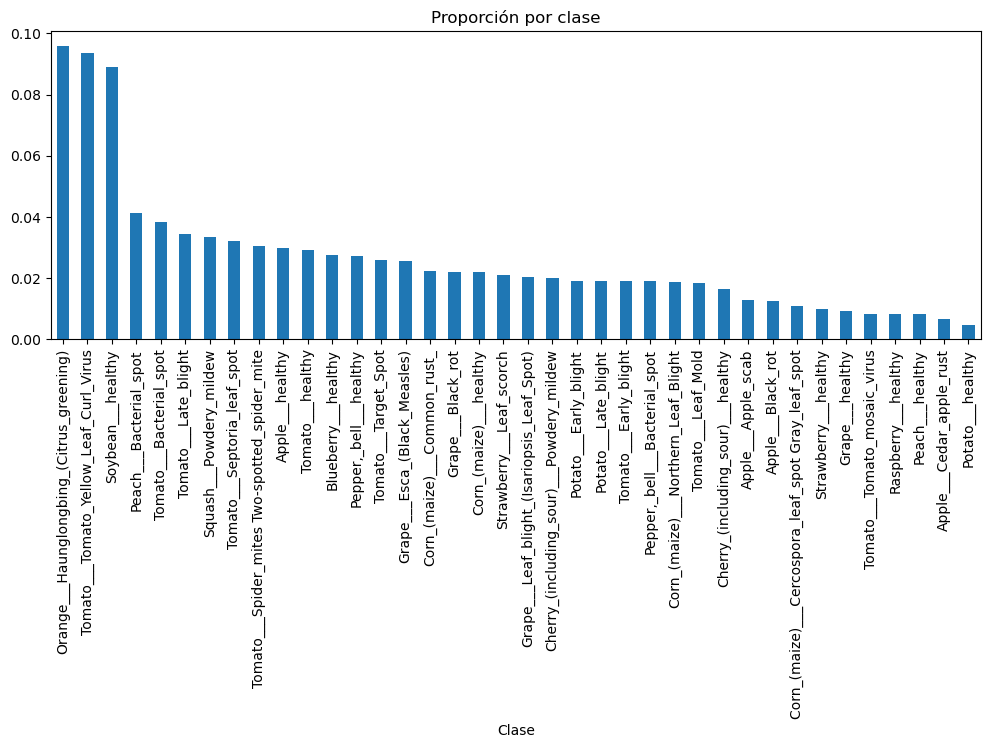

,Clase,Cantidad,Proporción
15,Orange___Haunglongbing_(Citrus_greening),5612,0.095999
37,Tomato___Tomato_Yellow_Leaf_Curl_Virus,5467,0.093519
24,Soybean___healthy,5200,0.088951
16,Peach___Bacterial_spot,2407,0.041174
28,Tomato___Bacterial_spot,2237,0.038266
31,Tomato___Late_blight,2011,0.034400
25,Squash___Powdery_mildew,1945,0.033271
33,Tomato___Septoria_leaf_spot,1881,0.032176
34,Tomato___Spider_mites Two-spotted_spider_mite,1786,0.030551
3,Apple___healthy,1748,0.029901


In [4]:
df_clases["Proporción"] = df_clases["Cantidad"] / df_clases["Cantidad"].sum()
df_clases.plot(kind='bar', x='Clase', y='Proporción', figsize=(12,4), legend=False, title="Proporción por clase")
plt.xticks(rotation=90)
plt.tight_layout()
plt.show()
df_clases


## Resoluciones comunes (muestra aleatoria de 100 imágenes)

In [5]:
resoluciones = []
muestra = random.sample(docs, min(100, len(docs)))
for d in muestra:
    try:
        url = d["imagen_rgb"]
        img = Image.open(BytesIO(requests.get(url).content))
        resoluciones.append(img.size)
    except:
        continue

pd.Series(resoluciones).value_counts().head(10)


: 

: 

# 🖼️ Visualización de imágenes por clase

In [ ]:
def mostrar_imagenes_de_clase(clase_nombre, n=5):
    clase_id = next((_id for _id, nombre in clases.items() if nombre == clase_nombre), None)
    if clase_id is None:
        print(f"Clase '{clase_nombre}' no encontrada.")
        return

    ejemplos = [d for d in docs if d.get("clase") == clase_id]
    if not ejemplos:
        print(f"No hay imágenes para la clase '{clase_nombre}'.")
        return

    muestra = random.sample(ejemplos, min(n, len(ejemplos)))
    fig, axs = plt.subplots(1, len(muestra), figsize=(15, 4))
    fig.suptitle(clase_nombre, fontsize=16)
    for ax, doc in zip(axs, muestra):
        try:
            img = Image.open(BytesIO(requests.get(doc["imagen_rgb"]).content))
            ax.imshow(img)
            ax.axis("off")
        except:
            ax.set_title("Error")
            ax.axis("off")
    plt.tight_layout()
    plt.show()


In [ ]:
for clase in random.sample(list(clases.values()), 5):
    mostrar_imagenes_de_clase(clase, n=5)


## Comparación entre formatos (Color, Grayscale, Segmentado)

In [6]:
def mostrar_formato_imagenes(clase_nombre, n=3):
    clase_id = next((_id for _id, nombre in clases.items() if nombre == clase_nombre), None)
    if clase_id is None:
        print(f"Clase '{clase_nombre}' no encontrada.")
        return

    formatos_dict = {v: k for k, v in formatos.items()}
    muestras_color = [d for d in docs if d.get("clase") == clase_id and d.get("formato") == formatos_dict.get("Color")]
    muestra = random.sample(muestras_color, min(n, len(muestras_color)))

    for doc in muestra:
        fig, axs = plt.subplots(1, 3, figsize=(12, 4))
        fig.suptitle(clase_nombre, fontsize=14)
        for i, fmt in enumerate(["Color", "Grayscale", "Segmented"]):
            formato_id = formatos_dict.get(fmt)
            if formato_id is None:
                axs[i].set_title(f"{fmt}(no definido)")
                axs[i].axis("off")
                continue
            ruta = next((d["imagen_rgb"] for d in docs if d.get("clase") == clase_id and d.get("formato") == formato_id and d["imagen_rgb"].split('/')[-1] == doc["imagen_rgb"].split('/')[-1]), None)
            if ruta:
                try:
                    img = Image.open(BytesIO(requests.get(ruta).content))
                    axs[i].imshow(img)
                    axs[i].set_title(fmt)
                    axs[i].axis("off")
                except:
                    axs[i].set_title(f"{fmt}Error")
                    axs[i].axis("off")
            else:
                axs[i].set_title(f"{fmt}No encontrada")
                axs[i].axis("off")
        plt.tight_layout()
        plt.show()


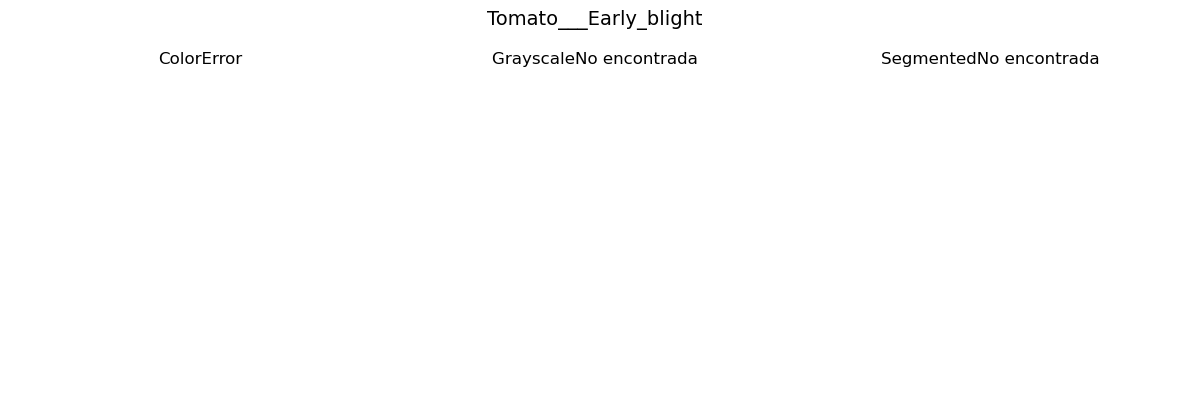

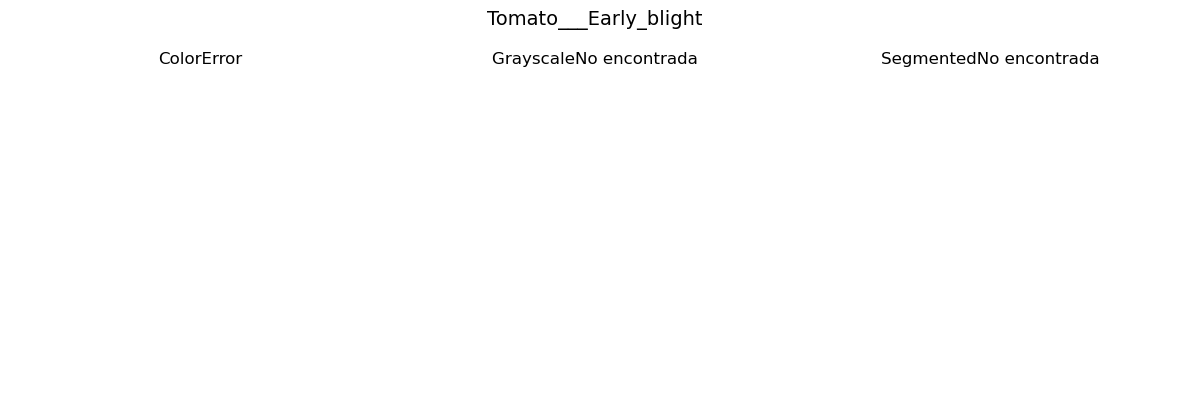

In [7]:
mostrar_formato_imagenes("Tomato___Early_blight", n=2)
